# Ternary Plug-and-Play Simulation

## Goal
In this tutorial, you will learn how to run a forward simulation with **two cosolutes** using the ternary crowding model. 

We will simulate a protein in a mixture of two contrasting cosolutes:
- **Urea:** A destabilizer (denaturant) that typically unfolds proteins.
- **TMAO:** A strong stabilizer (osmolyte) that counters the effect of Urea.

## Setup
We begin by importing the package and `matplotlib.pyplot`.

In [1]:
import fh_crowding
import matplotlib.pyplot as plt
import numpy as np

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Define the Components
We need to define the Protein, the two individual Cosolutes, and then combine the cosolutes into a `CosoluteMixture`.

1. **Protein (AQ16):** SASA = 242.6 $A^2$.
2. **Cosolute 2 (Urea):** $\nu_2=2.479$, $\chi_{12}=0.610$, $\chi_{TS,12}=-3.650$. It has a destabilizing soft interaction (e.g. $\varepsilon_2 = -0.5$).
3. **Cosolute 3 (TMAO):** $\nu_3=3.980$, $\chi_{13}=-0.680$, $\chi_{TS,13}=-5.708$. It has a stabilizing soft interaction (e.g. $\varepsilon_3 = 0.5$).
4. **Cosolute-Cosolute Interactions:** $\chi_{23}=0.963$, $chi_{TS,23}=-38.810$

In [2]:
# Define Protein
protein = fh_crowding.Protein(SASA=242.6)

# Combine into a mixture. Note that the cross interaction chi23 is 0 by default.
mixture = fh_crowding.CosoluteMixture(
    nu2=2.479, nu3=3.980, 
    chi12=0.610, chi13=-0.680, chi23=0.963, 
    chiTS12=-3.650, chiTS13=-5.708, chiTS23=-38.810
)

## Build and Solve the Ternary Model
We construct the `TernaryCrowdingModel`. 

Because a ternary model solves the equilibrium across a **2D grid** of concentrations (for both Urea and TMAO), the memory and computation time grow quadratically. To keep this tutorial fast, we will simulate up to $\phi=0.10$ with a coarse step `dphiC=0.005`.

*Note: For the ternary model, $\varepsilon_2$ and $\varepsilon_3$ correspond to the soft interactions with Cosolute 2 and 3 respectively.*

In [3]:
model = fh_crowding.TernaryCrowdingModel(
    protein=protein,
    cosolutes=mixture,
    eps2=-0.5,        # Urea destabilizes
    eps3=0.5,         # TMAO stabilizes
    epsTS2=0.0,
    epsTS3=0.0,
    phi2_max=0.35,    # Covers 6 m Urea
    phi3_max=0.25,    # Covers 4 m TMAO
    dphi2=0.01,       # Coarse grid for faster computation
    dphi3=0.01,
    T=298.15
)

# Solve the thermodynamic equilibrium across the 2D grid
model.solve_equil()

## Extract and Visualize Results
The ternary model calculates properties across a 2D grid. We can visualize these as heatmaps or contour plots.

The `TernaryPlotter` class automatically handles this visualization.

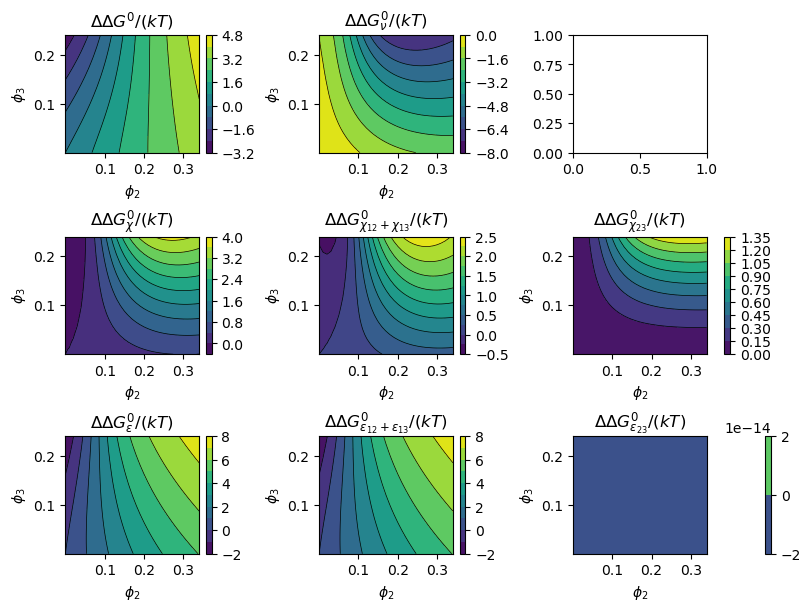

In [4]:
from fh_crowding.plotting import TernaryPlotter

plotter = TernaryPlotter(model)

# Plot the 2D contour map for Delta Delta G
fig = plotter.plot_ddG()
plt.show()

### Interpretation
- The x-axis represents the volume fraction of Cosolute 2 (Urea).
- The y-axis represents the volume fraction of Cosolute 3 (TMAO).
- The color gradient indicates the stability ($\Delta\Delta G$) of the protein.
  - Moving right (increasing Urea) causes $\Delta\Delta G$ to become more positive (destabilization).
  - Moving up (increasing TMAO) causes $\Delta\Delta G$ to become more negative (stabilization).
  

Parameters can be set directly and the model can be solved from the start

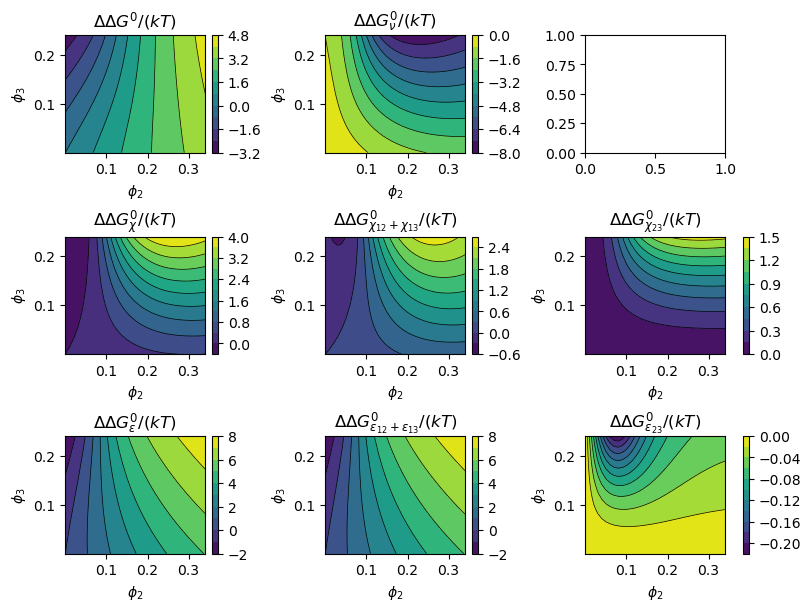

In [5]:
model.eps23=0.6
# Solve the thermodynamic equilibrium across the 2D grid
model.solve_equil()
plotter = TernaryPlotter(model)

# Plot the 2D contour map for Delta Delta G
fig = plotter.plot_ddG()
plt.show()

## Exporting Results
Just like the binary model, we can export the 2D grid of results to a pandas DataFrame.

In [6]:
# Convert 2D results to DataFrame (it will flatten the 2D grid into rows)
model.to_pandas()
results = model.results

display(results.head())
# results.to_csv("ternary_simulation_results.csv", index=False)
print("Simulation complete! You have successfully run a ternary mixture.")

,phi1,phi2,phi3,phi1s,phi2s,phi3s,phi1s2,phi2s2,phi1s3,phi2s3,...,TddS_eps12_eps13_kJ,TddS_eps23_kJ,TddS_kJ,mu1,mu2,mu3,Gamma2,Gamma3,Gamma12,Gamma13
0,0.9998,0.0001,0.0001,0.999803,0.000174,0.000023,0.999781,0.000219,0.999778,0.000193,...,0.0,1.292623e-07,0.002877,-0.000065,-9.177006,-14.895481,-0.001183,0.000768,-30.563472,29.328577
1,0.9898,0.0101,0.0001,0.982430,0.017549,0.000022,0.978073,0.021927,0.980464,0.019509,...,0.0,1.216304e-05,0.156397,-0.004090,-4.577186,-14.853243,-0.120856,0.000777,-30.593004,29.361004
2,0.9798,0.0201,0.0001,0.965058,0.034922,0.000020,0.956682,0.043318,0.961215,0.038760,...,0.0,2.252010e-05,0.276863,-0.008095,-3.904000,-14.810520,-0.242946,0.000784,-30.573945,29.358139
3,0.9698,0.0301,0.0001,0.947715,0.052266,0.000019,0.935618,0.064382,0.942064,0.057914,...,0.0,3.133763e-05,0.364076,-0.012081,-3.514890,-14.767311,-0.367063,0.000790,-30.508689,29.317930
4,0.9598,0.0401,0.0001,0.930432,0.069550,0.000017,0.914895,0.085105,0.923043,0.076936,...,0.0,3.875411e-05,0.418337,-0.016052,-3.242432,-14.723617,-0.492770,0.000796,-30.399915,29.238653


Simulation complete! You have successfully run a ternary mixture.
